# Tracked Cell — Comprehensive Visualization

For each tracked cell, generates one figure containing:
- **FOV row**: mean-image crop with ROI footprint highlighted per day
- **Spatial maps**: heatmap (sessions × bins) + per-day tuning curves
- **Metrics**: SMI, reliability (avg_cc), preferred position, landmark preference

Output: one PDF with one page per cell.

In [49]:
import sys
sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")

import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
rcParams['legend.fontsize']  = 11
rcParams['axes.labelsize']   = 11
rcParams['axes.titlesize']   = 12
rcParams['xtick.labelsize']  = 10
rcParams['ytick.labelsize']  = 10

import h5py
from glob import glob
from pathlib import Path
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter1d

# load_tracked utilities (same folder)
os.chdir(os.path.dirname(os.path.abspath('TrackedCell_ComprehensiveVisualization.ipynb')))
from load_tracked import (
    load_tracking, filter_to_analysis_days,
    find_files_from_tracking, find_smi_files, find_preproc_files,
    assign_layers_from_smi, load_smi_session, load_preproc_session,
    build_matrix, build_reliability_mask,
    parse_day_numbers, animal_id_from_path,
    LAYER_ORDER, LAYER_COLORS,
)

print('Imports OK')

Imports OK


## Configuration

In [50]:
# ── paths ──────────────────────────────────────────────────────
ROI_TRACKING_FILE = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\TrackedROIs\roi_tracking_results.h5"
ANIMAL_DIR        = r"D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging"
OUTPUT_DIR        = os.path.join(ANIMAL_DIR, "TrackedROIs","comprehensive2357")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── sessions ───────────────────────────────────────────────────
REFERENCE_DAY  = "Day2"
ANALYSIS_DAYS  = ['Day2','Day3','Day5', 'Day7']   # None = all

# ── landmark parameters ────────────────────────────────────────
LANDMARK_POSITIONS = [37, 65, 93, 120]          # cm
LANDMARK_WINDOWS_CONFIG = [
    {'before': 25, 'after': 0},   # L1 at 37cm:  [12, 37]
    {'before': 25, 'after': 0},   # L2 at 65cm:  [40, 65]
    {'before': 25, 'after': 0},   # L3 at 93cm:  [68, 93]
    {'before': 25, 'after': 0},   # L4 at 120cm: [95, 120]
]
LANDMARK_COLORS    = ['#E41A1C','#377EB8','#4DAF4A','#984EA3']
LANDMARK_LABELS    = [f'L{i+1} ({p}cm)' for i, p in enumerate(LANDMARK_POSITIONS)]
EXCLUDE_FIRST_BINS = 10
EXCLUDE_LAST_BINS  = 10

# ── cell selection ─────────────────────────────────────────────
# 'reliable_cells' | 'combined_reliable' | 'reliable_valid_cells'
CELL_SELECTION = 'combined_reliable'
FIXED_POOL     = True      # evaluate reliability on REFERENCE_DAY only

# ── output ─────────────────────────────────────────────────────
# None = all cells; or a list of row-indices into tracked_matrix
CELLS_TO_PLOT  = None
CROP_SIZE      = 40        # pixels around ROI centroid for FOV panel
SMOOTH_SIGMA   = 1.0

## Load tracking & files

In [51]:
tracked_matrix, day_labels, session_dirs = load_tracking(ROI_TRACKING_FILE)

tracked_matrix, day_labels, session_dirs = filter_to_analysis_days(
    tracked_matrix, day_labels, session_dirs, ANALYSIS_DAYS
)

session_days = parse_day_numbers(day_labels)
n_sessions   = len(day_labels)
n_tracked    = tracked_matrix.shape[0]
animal_id    = animal_id_from_path(ROI_TRACKING_FILE)

# File maps
smi_files    = find_files_from_tracking(session_dirs, '*_smi_results.h5')
preproc_files= find_files_from_tracking(session_dirs, '*_preproc*.h5')

print(f"Animal: {animal_id}")
print(f"Tracked cells: {n_tracked}, Sessions: {day_labels}")
print(f"SMI files:     {list(smi_files.keys())}")
print(f"Preproc files: {list(preproc_files.keys())}")

  Tracked cells: 162, Sessions: 6
  Day labels   : ['Day2', 'Day3', 'Day4', 'Day5', 'Day6', 'Day7']
  filter_to_analysis_days: ['Day2', 'Day3', 'Day5', 'Day7']
  Cells before: 162  →  after: 162 (dropped 0 missing a valid ROI in ≥1 session)
Animal: JSY054
Tracked cells: 162, Sessions: ['Day2', 'Day3', 'Day5', 'Day7']
SMI files:     ['Day2', 'Day3', 'Day5', 'Day7']
Preproc files: ['Day2', 'Day3', 'Day5', 'Day7']


## Layer assignment

In [52]:
cell_layers = assign_layers_from_smi(
    tracked_matrix, day_labels, smi_files, REFERENCE_DAY
)
# Map each tracked-cell row to its layer name
row_to_layer = np.full(n_tracked, '', dtype=object)
for lname, rows in cell_layers.items():
    for r in rows:
        row_to_layer[r] = lname

for ln, rows in cell_layers.items():
    print(f"  {ln}: {len(rows)} cells")

  L2/3: 8 cells
  L4: 74 cells
  L5: 60 cells
  L6: 20 cells


## Build per-session data matrices

In [53]:
# ── SMI ────────────────────────────────────────────────────────
def _ext_smi(f, rois):
    smi, _, _, _, _, _ = load_smi_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(smi): out[i] = smi[r]
    return out

def _ext_rp(f, rois):
    _, _, Rp, _, _, _ = load_smi_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(Rp): out[i] = Rp[r]
    return out

def _ext_rn(f, rois):
    _, _, _, Rn, _, _ = load_smi_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(Rn): out[i] = Rn[r]
    return out

def _ext_pref_pos(f, rois):
    _, _, _, _, pp, _ = load_smi_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(pp): out[i] = pp[r]
    return out

def _ext_cc(f, rois):
    _, _, bc, _, cc, _, _ = load_preproc_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(cc): out[i] = cc[r]
    return out

def _ext_cohen(f, rois):
    _, _, _, _, _, cd, _ = load_preproc_session(f)
    out = np.full(len(rois), np.nan)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(cd): out[i] = cd[r]
    return out

smi_matrix   = build_matrix(tracked_matrix, day_labels, smi_files,    _ext_smi)
rp_matrix    = build_matrix(tracked_matrix, day_labels, smi_files,    _ext_rp)
rn_matrix    = build_matrix(tracked_matrix, day_labels, smi_files,    _ext_rn)
pref_pos_mat = build_matrix(tracked_matrix, day_labels, smi_files,    _ext_pref_pos)
cc_matrix    = build_matrix(tracked_matrix, day_labels, preproc_files, _ext_cc)
cd_matrix    = build_matrix(tracked_matrix, day_labels, preproc_files, _ext_cohen)

print('SMI matrix:     ', smi_matrix.shape, '  non-NaN:', np.sum(~np.isnan(smi_matrix)))
print('avg_cc matrix:  ', cc_matrix.shape,  '  non-NaN:', np.sum(~np.isnan(cc_matrix)))

SMI matrix:      (162, 4)   non-NaN: 312
avg_cc matrix:   (162, 4)   non-NaN: 648


In [54]:
# ── Combined-reliable and reliable_valid_cells boolean matrices ────────────
# comb_rel_matrix[row, col]  = True if cell is combined_reliable that session
# rv_matrix[row, col]        = True if cell is reliable_valid_cells that session

def _ext_comb_rel(f, rois):
    with h5py.File(f, 'r') as hf:
        key = 'combined_reliable' if 'combined_reliable' in hf else 'reliable_cells'
        rel = hf[key][:].astype(bool)
    out = np.zeros(len(rois), dtype=bool)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(rel):
            out[i] = rel[r]
    return out.astype(float)

def _ext_rv(f, rois):
    n_max = int(np.max(rois[rois >= 0])) + 1 if np.any(rois >= 0) else 0
    rv = np.zeros(n_max, dtype=bool)
    with h5py.File(f, 'r') as hf:
        if 'layer_smi' in hf:
            for lk in hf['layer_smi'].keys():
                grp = hf['layer_smi'][lk]
                if 'reliable_valid_cells' in grp:
                    idx = grp['reliable_valid_cells'][:].astype(int)
                    idx = idx[idx < n_max]
                    rv[idx] = True
    out = np.zeros(len(rois), dtype=bool)
    for i, r in enumerate(rois):
        if r >= 0 and r < len(rv):
            out[i] = rv[r]
    return out.astype(float)

comb_rel_matrix = build_matrix(tracked_matrix, day_labels, preproc_files, _ext_comb_rel, fill=0.0).astype(bool)
rv_matrix       = build_matrix(tracked_matrix, day_labels, smi_files,     _ext_rv,       fill=0.0).astype(bool)

print('combined_reliable matrix:', comb_rel_matrix.shape,
      '  True cells (any session):', np.sum(np.any(comb_rel_matrix, axis=1)))
print('reliable_valid_cells matrix:', rv_matrix.shape,
      '  True cells (any session):', np.sum(np.any(rv_matrix, axis=1)))

combined_reliable matrix: (162, 4)   True cells (any session): 152
reliable_valid_cells matrix: (162, 4)   True cells (any session): 136


## Landmark preference matrices

In [55]:
from scipy.ndimage import gaussian_filter1d

def get_preferred_landmark(nsa, bin_centers, lm_positions, lm_windows_config,
                            excl_first=10, excl_last=10, sigma=1.0):
    """
    Returns preferred_lm (n_cells,) int, -1=invalid.
    lm_windows_config: list of {'before': float, 'after': float} per landmark.
    """
    n_cells, n_trials, n_bins = nsa.shape
    bs   = np.mean(np.diff(bin_centers))
    t_lo = bin_centers[0]  + excl_first * bs
    t_hi = bin_centers[-1] - excl_last  * bs

    windows = [(p - cfg['before'], p + cfg['after'])
               for p, cfg in zip(lm_positions, lm_windows_config)]

    mean_p = np.mean(nsa, axis=1)
    if sigma > 0:
        for c in range(n_cells):
            mean_p[c] = gaussian_filter1d(mean_p[c], sigma=sigma)

    pref = np.full(n_cells, -1, dtype=int)
    for cell in range(n_cells):
        pk_idx = np.argmax(mean_p[cell])
        pk_pos = bin_centers[pk_idx]
        if mean_p[cell, pk_idx] == 0 or pk_pos < t_lo or pk_pos > t_hi:
            continue
        hits = [(i, np.max(mean_p[cell, (bin_centers >= w[0]) & (bin_centers <= w[1])]))
                for i, w in enumerate(windows)
                if w[0] <= pk_pos <= w[1] and np.any((bin_centers >= w[0]) & (bin_centers <= w[1]))]
        if hits:
            pref[cell] = max(hits, key=lambda x: x[1])[0]
    return pref

lm_matrix = np.full((n_tracked, n_sessions), -1, dtype=int)

for col, day in enumerate(day_labels):
    if day not in preproc_files:
        continue
    _, nsa, bc, _, _, _, _ = load_preproc_session(preproc_files[day])
    bc_s = bc - np.min(bc)
    bc_s = bc_s * (len(bc_s) / np.max(bc_s)) if np.max(bc_s) > 0 else bc_s
    pref = get_preferred_landmark(nsa, bc_s, LANDMARK_POSITIONS, LANDMARK_WINDOWS_CONFIG,
                                  EXCLUDE_FIRST_BINS, EXCLUDE_LAST_BINS, SMOOTH_SIGMA)
    for row, roi in enumerate(tracked_matrix[:, col]):
        if roi >= 0 and roi < len(pref):
            lm_matrix[row, col] = pref[roi]
    print(f"  {day}: {np.sum(lm_matrix[:, col] >= 0)} cells with valid landmark pref")

print('Done building landmark matrix.')

  Day2: 90 cells with valid landmark pref
  Day3: 74 cells with valid landmark pref
  Day5: 31 cells with valid landmark pref
  Day7: 55 cells with valid landmark pref
Done building landmark matrix.


## Load spatial tuning curves per session

In [56]:
# tuning_curves[col] = (n_cells_this_session, n_bins)  — row-normalised mean
# bin_centers_sessions[col] = (n_bins,)
tuning_curves       = {}   # col -> (n_tracked, n_bins) — NaN if absent
bin_centers_by_day  = {}

for col, day in enumerate(day_labels):
    if day not in preproc_files:
        continue
    _, nsa, bc, _, _, _, _ = load_preproc_session(preproc_files[day])
    bc_s = bc - np.min(bc)
    bc_s = bc_s * (len(bc_s) / np.max(bc_s)) if np.max(bc_s) > 0 else bc_s
    bin_centers_by_day[col] = bc_s

    mean_p = np.mean(nsa, axis=1)  # (n_cells, n_bins)
    if SMOOTH_SIGMA > 0:
        for c in range(mean_p.shape[0]):
            mean_p[c] = gaussian_filter1d(mean_p[c], sigma=SMOOTH_SIGMA)

    # Row-normalise
    mn = mean_p.min(axis=1, keepdims=True)
    mx = mean_p.max(axis=1, keepdims=True)
    denom = np.where(mx - mn > 0, mx - mn, 1.0)
    mean_norm = (mean_p - mn) / denom

    # Map tracked rows -> tuning curve
    out = np.full((n_tracked, mean_norm.shape[1]), np.nan)
    for row, roi in enumerate(tracked_matrix[:, col]):
        if roi >= 0 and roi < mean_norm.shape[0]:
            out[row] = mean_norm[roi]
    tuning_curves[col] = out

# Use reference-day bin centers for plotting
ref_col = day_labels.index(REFERENCE_DAY)
bin_centers_ref = bin_centers_by_day.get(ref_col, None)
print(f'Tuning curves loaded for {len(tuning_curves)} sessions.')
print(f'Bin centers (ref day): {bin_centers_ref[[0,-1]] if bin_centers_ref is not None else None}')

Tuning curves loaded for 4 sessions.
Bin centers (ref day): [  0. 130.]


## Pre-load trial-by-trial activity (for per-cell raster plots)

In [57]:
# Load full NSA arrays for first and last sessions only (memory-efficient).
# nsa_sessions = {col_index: (nsa (n_cells, n_trials, n_bins), bc_scaled)}
nsa_sessions = {}

for col in sorted({0, n_sessions - 1}):
    day = day_labels[col]
    if day not in preproc_files:
        print(f"  WARNING: no preproc file for {day}")
        continue
    _, nsa, bc, _, _, _, _ = load_preproc_session(preproc_files[day])
    bc_s = bc - np.min(bc)
    bc_s = bc_s * (len(bc_s) / np.max(bc_s)) if np.max(bc_s) > 0 else bc_s
    nsa_sessions[col] = (nsa, bc_s)
    print(f"  Loaded NSA for {day}: shape {nsa.shape}")

print(f"NSA preloaded for cols: {list(nsa_sessions.keys())}")

  Loaded NSA for Day2: shape (944, 107, 130)
  Loaded NSA for Day7: shape (1033, 106, 130)
NSA preloaded for cols: [0, 3]


## Load suite2p FOV data (stat + mean images)

In [58]:
# Load suite2p stat and mean images for FOV panel
# fov_data[day] = {'stat': list, 'mean_img': ndarray, 'Ly': int, 'Lx': int,
#                  'cell_idx': ndarray}
fov_data = {}

with h5py.File(ROI_TRACKING_FILE, 'r') as f:
    session_grp = f.get('sessions', {})
    for day_key in session_grp.keys():
        if day_key not in day_labels:
            continue
        grp = session_grp[day_key]
        if 'plane0_path' not in grp.attrs:
            continue
        raw = grp.attrs['plane0_path']
        plane0 = raw.decode() if isinstance(raw, bytes) else str(raw)
        p = Path(plane0)
        if not p.exists():
            print(f'  WARNING: plane0 not found for {day_key}: {plane0}')
            continue

        stat   = np.load(p / 'stat.npy', allow_pickle=True)
        iscell = np.load(p / 'iscell.npy', allow_pickle=True)
        ops    = np.load(p / 'ops.npy',    allow_pickle=True).item()

        cell_idx = np.where(iscell[:, 0] == 1)[0]
        stat_cells = [stat[i] for i in cell_idx]

        fov_data[day_key] = {
            'stat':     stat_cells,
            'mean_img': ops['meanImg'],
            'Ly': ops['Ly'],
            'Lx': ops['Lx'],
            'cell_idx': cell_idx,
        }
        print(f'  Loaded FOV: {day_key} — {len(stat_cells)} cells')

print(f'FOV data available for: {list(fov_data.keys())}')

  Loaded FOV: Day2 — 944 cells
  Loaded FOV: Day3 — 929 cells
  Loaded FOV: Day5 — 808 cells
  Loaded FOV: Day7 — 1033 cells
FOV data available for: ['Day2', 'Day3', 'Day5', 'Day7']


## Determine cells to plot

In [59]:
if CELLS_TO_PLOT is None:
    # Only include cells that have valid SMI in at least one session
    has_smi = np.any(~np.isnan(smi_matrix), axis=1)
    cells_to_plot = np.where(has_smi)[0]
else:
    cells_to_plot = np.array(CELLS_TO_PLOT)

print(f'Cells to plot: {len(cells_to_plot)}')

Cells to plot: 136


In [60]:
DAY_CMAP   = plt.cm.viridis
DAY_COLORS = [DAY_CMAP(i / max(n_sessions - 1, 1)) for i in range(n_sessions)]

TUNING_X_MIN  = 5     # cm
TUNING_X_MAX  = 125    # cm
WATERFALL_GAP = 1.3    # vertical spacing between waterfall traces

FS_SUPTITLE  = 16
FS_TITLE     = 13
FS_LABEL     = 12
FS_TICK      = 11
FS_LEGEND    = 10
FS_FOV_TITLE = 10
FS_REL_TEXT  = 9


def make_footprint_image(stat, roi_idx, Ly, Lx):
    fp = np.zeros((Ly, Lx), dtype=np.float32)
    s  = stat[roi_idx]
    fp[s['ypix'], s['xpix']] = s['lam']
    if fp.max() > 0:
        fp /= fp.max()
    return fp


def get_centroid(stat_cell):
    lam   = stat_cell['lam']
    lam_n = lam / lam.sum()
    return np.sum(stat_cell['ypix'] * lam_n), np.sum(stat_cell['xpix'] * lam_n)


def plot_cell_figure(cell_row):
    layer_name = row_to_layer[cell_row]
    layer_col  = LAYER_COLORS.get(layer_name, 'gray')

    n_fov_cols = n_sessions + 1
    # 5 rows: FOV | Tuning | SMI/CC | Pref pos/LM | Rasters (first/last day)
    fig = plt.figure(figsize=(max(18, n_fov_cols * 2.4), 20))
    outer = gridspec.GridSpec(
        5, 1, figure=fig,
        height_ratios=[2.5, 2.2, 1.8, 1.8, 2.2],
        hspace=0.60, top=0.94, bottom=0.04, left=0.07, right=0.97
    )
    fov_gs  = gridspec.GridSpecFromSubplotSpec(1, n_fov_cols, subplot_spec=outer[0], wspace=0.05)
    map_gs  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1],
                                               width_ratios=[1, 1], wspace=0.38)
    met1_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.45)
    met2_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.45)
    rast_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[4], wspace=0.38)

    fig.suptitle(f"{animal_id}  —  Tracked Cell {cell_row}  [{layer_name}]",
                 fontsize=FS_SUPTITLE, fontweight='bold')

    # ── ROW 0: FOV ───────────────────────────────────────────────────────────
    crop_sz     = CROP_SIZE
    ref_day     = REFERENCE_DAY
    ref_col_idx = day_labels.index(ref_day)
    ref_roi     = tracked_matrix[cell_row, ref_col_idx]

    if ref_day in fov_data and ref_roi >= 0 and ref_roi < len(fov_data[ref_day]['stat']):
        ref_cy, ref_cx = get_centroid(fov_data[ref_day]['stat'][ref_roi])
        Ly_ref, Lx_ref = fov_data[ref_day]['Ly'], fov_data[ref_day]['Lx']
        ref_mean_img   = fov_data[ref_day]['mean_img']
    else:
        first_day = next((d for d in day_labels if d in fov_data), None)
        if first_day:
            fd0 = fov_data[first_day]
            r0  = tracked_matrix[cell_row, day_labels.index(first_day)]
            ref_cy, ref_cx = get_centroid(fd0['stat'][r0]) if r0 >= 0 else (fd0['Ly']/2, fd0['Lx']/2)
            Ly_ref, Lx_ref, ref_mean_img = fd0['Ly'], fd0['Lx'], fd0['mean_img']
        else:
            ref_cy, ref_cx, Ly_ref, Lx_ref = 100, 100, 200, 200
            ref_mean_img = np.zeros((200, 200))

    comp_y0 = int(max(0, ref_cy - crop_sz));  comp_y1 = int(min(Ly_ref, ref_cy + crop_sz))
    comp_x0 = int(max(0, ref_cx - crop_sz));  comp_x1 = int(min(Lx_ref, ref_cx + crop_sz))
    comp_h, comp_w = comp_y1 - comp_y0, comp_x1 - comp_x0
    comp_bg = ref_mean_img[comp_y0:comp_y1, comp_x0:comp_x1]

    overlay_cols = plt.cm.hsv(np.linspace(0, 0.85, n_sessions))
    comp_ov      = np.zeros((comp_h, comp_w, 4))
    shifted_fps  = {}

    for i, day in enumerate(day_labels):
        ax_fov = fig.add_subplot(fov_gs[i])
        ax_fov.set_xticks([]); ax_fov.set_yticks([])


        if day not in fov_data:
            ax_fov.text(0.5, 0.5, 'no\nFOV', ha='center', va='center',
                        transform=ax_fov.transAxes, fontsize=FS_FOV_TITLE)
            ax_fov.set_title(day, fontsize=FS_FOV_TITLE)
            continue

        fd  = fov_data[day]
        roi = tracked_matrix[cell_row, day_labels.index(day)]
        if roi < 0 or roi >= len(fd['stat']):
            ax_fov.text(0.5, 0.5, 'absent', ha='center', va='center',
                        transform=ax_fov.transAxes, fontsize=FS_FOV_TITLE)
            ax_fov.set_title(day, fontsize=FS_FOV_TITLE)
            continue

        cy_d, cx_d = get_centroid(fd['stat'][roi])
        y0 = int(max(0, cy_d - crop_sz));  y1 = int(min(fd['Ly'], cy_d + crop_sz))
        x0 = int(max(0, cx_d - crop_sz));  x1 = int(min(fd['Lx'], cx_d + crop_sz))

        fp_full   = make_footprint_image(fd['stat'], roi, fd['Ly'], fd['Lx'])
        fp_crop   = fp_full[y0:y1, x0:x1]
        mean_crop = fd['mean_img'][y0:y1, x0:x1]

        ax_fov.imshow(mean_crop, cmap='gray', origin='upper')
        ov = np.zeros((*fp_crop.shape, 4))
        ov[:, :, 1] = fp_crop;  ov[:, :, 3] = fp_crop * 0.7
        ax_fov.imshow(ov, origin='upper')

        ax_fov.set_title(f'{day}  ROI {roi}', fontsize=FS_FOV_TITLE)

        dy = int(round(ref_cy - cy_d));  dx = int(round(ref_cx - cx_d))
        # Offset crop instead of shifting full image (much faster)
        sy0 = comp_y0 - dy;  sy1 = comp_y1 - dy
        sx0 = comp_x0 - dx;  sx1 = comp_x1 - dx
        fp_s_crop = np.zeros((comp_h, comp_w), dtype=np.float32)
        vy0, vy1 = max(0, sy0), min(fd['Ly'], sy1)
        vx0, vx1 = max(0, sx0), min(fd['Lx'], sx1)
        if vy1 > vy0 and vx1 > vx0:
            dst_y0 = vy0 - sy0;  dst_y1 = dst_y0 + (vy1 - vy0)
            dst_x0 = vx0 - sx0;  dst_x1 = dst_x0 + (vx1 - vx0)
            fp_s_crop[dst_y0:dst_y1, dst_x0:dst_x1] = fp_full[vy0:vy1, vx0:vx1]
        shifted_fps[i] = fp_s_crop
        c = overlay_cols[i];  mask = fp_s_crop > 0.1
        comp_ov[mask, 0] += c[0] * fp_s_crop[mask]
        comp_ov[mask, 1] += c[1] * fp_s_crop[mask]
        comp_ov[mask, 2] += c[2] * fp_s_crop[mask]
        comp_ov[mask, 3]  = np.maximum(comp_ov[mask, 3], fp_s_crop[mask] * 0.7)

    ax_comp = fig.add_subplot(fov_gs[n_sessions])
    ax_comp.set_xticks([]); ax_comp.set_yticks([])
    ax_comp.set_title('All days\noverlaid', fontsize=FS_FOV_TITLE)
    ax_comp.imshow(comp_bg, cmap='gray', origin='upper')
    comp_ov[:, :, :3] = np.clip(comp_ov[:, :, :3], 0, 1)
    ax_comp.imshow(comp_ov, origin='upper')
    for i, fp_s_crop in shifted_fps.items():
        if fp_s_crop.max() > 0.1:
            try:
                ax_comp.contour(fp_s_crop, levels=[0.25], colors=[overlay_cols[i, :3]],
                                linewidths=1.2, alpha=0.9)
            except Exception:
                pass

    # ── ROW 1: Tuning heatmap | Waterfall ────────────────────────────────────
    ax_hmap = fig.add_subplot(map_gs[0])
    ax_line = fig.add_subplot(map_gs[1])

    bc_plot   = bin_centers_ref
    hmap_data = []
    for col, day in enumerate(day_labels):
        if col not in tuning_curves:
            hmap_data.append(np.full(len(bc_plot) if bc_plot is not None else 110, np.nan))
        else:
            tc = tuning_curves[col][cell_row]
            if bc_plot is None:
                bc_plot = bin_centers_by_day.get(col)
            if len(tc) != len(bc_plot):
                bc_src = bin_centers_by_day.get(col, np.linspace(0, 130, len(tc)))
                tc = np.interp(bc_plot, bc_src, tc)
            hmap_data.append(tc)

    hmap_arr  = np.array(hmap_data)
    if bc_plot is not None:
        trim_mask = (bc_plot >= TUNING_X_MIN) & (bc_plot <= TUNING_X_MAX)
        bc_trim   = bc_plot[trim_mask]
        hmap_trim = hmap_arr[:, trim_mask]
    else:
        bc_trim = bc_plot;  hmap_trim = hmap_arr

    if bc_trim is not None and not np.all(np.isnan(hmap_trim)):
        im = ax_hmap.imshow(
            hmap_trim, aspect='auto', cmap='Blues', vmin=0, vmax=1,
            origin='upper', interpolation='nearest',
            extent=[TUNING_X_MIN, TUNING_X_MAX, n_sessions - 0.5, -0.5]
        )
        for lp, lc in zip(LANDMARK_POSITIONS, LANDMARK_COLORS):
            if TUNING_X_MIN <= lp <= TUNING_X_MAX:
                ax_hmap.axvline(lp, color=lc, lw=1, alpha=0.8, linestyle='--')
        ax_hmap.set_yticks(range(n_sessions))
        ax_hmap.set_yticklabels(day_labels, fontsize=FS_TICK)
        ax_hmap.set_xlim(TUNING_X_MIN, TUNING_X_MAX)
        ax_hmap.tick_params(axis='x', labelsize=FS_TICK)
        ax_hmap.set_xlabel('Position (cm)', fontsize=FS_LABEL)
        ax_hmap.set_title('Tuning curves\n(row-norm, sessions × bins)', fontsize=FS_TITLE)
        cbar = plt.colorbar(im, ax=ax_hmap, fraction=0.04, pad=0.02)
        cbar.ax.tick_params(labelsize=FS_TICK)
    else:
        ax_hmap.text(0.5, 0.5, 'No data', ha='center', va='center',
                     transform=ax_hmap.transAxes, fontsize=FS_LABEL)

    if bc_trim is not None:
        ytick_pos, ytick_lbl = [], []
        for col in range(n_sessions):
            tc     = hmap_trim[col]
            offset = (n_sessions - 1 - col) * WATERFALL_GAP
            if np.all(np.isnan(tc)):
                continue
            ax_line.plot(bc_trim, tc + offset, color=DAY_COLORS[col], linewidth=1.8)
            ax_line.fill_between(bc_trim, offset, tc + offset, color=DAY_COLORS[col], alpha=0.2)
            ytick_pos.append(offset + 0.5)
            ytick_lbl.append(day_labels[col])
        for lp, lc in zip(LANDMARK_POSITIONS, LANDMARK_COLORS):
            if TUNING_X_MIN <= lp <= TUNING_X_MAX:
                ax_line.axvline(lp, color=lc, lw=1, alpha=0.6, linestyle='--')
        ax_line.set_xlim(TUNING_X_MIN, TUNING_X_MAX)
        ax_line.set_yticks(ytick_pos)
        ax_line.set_yticklabels(ytick_lbl, fontsize=FS_TICK)
        ax_line.tick_params(axis='x', labelsize=FS_TICK)
        ax_line.set_xlabel('Position (cm)', fontsize=FS_LABEL)
        ax_line.set_title('Tuning curves per day\n(waterfall, Day2 top → Day7 bottom)', fontsize=FS_TITLE)
    else:
        ax_line.text(0.5, 0.5, 'No data', ha='center', va='center',
                     transform=ax_line.transAxes, fontsize=FS_LABEL)

    # ── ROW 2: SMI | avg_cc ──────────────────────────────────────────────────
    ax_smi = fig.add_subplot(met1_gs[0])
    ax_cc  = fig.add_subplot(met1_gs[1])
    x_days = np.array(session_days)

    smi_cell = smi_matrix[cell_row];  rp_cell = rp_matrix[cell_row];  rn_cell = rn_matrix[cell_row]
    valid_s  = ~np.isnan(smi_cell)
    if valid_s.any():
        ax_smi.plot(x_days[valid_s], smi_cell[valid_s], 'o-', color=layer_col, lw=2, ms=7, label='SMI', zorder=3)
        ax_smi.plot(x_days[valid_s], rp_cell[valid_s],  's--', color='steelblue', lw=1.5, ms=6, label='Rp', zorder=2)
        ax_smi.plot(x_days[valid_s], rn_cell[valid_s],  '^--', color='tomato', lw=1.5, ms=6, label='Rn', zorder=2)
        ax_smi.axhline(0, color='gray', lw=0.7, linestyle=':')
    ax_smi.set_xlabel('Day', fontsize=FS_LABEL)
    ax_smi.set_ylabel('SMI / Response', fontsize=FS_LABEL)
    ax_smi.set_title('Spatial Modulation Index', fontsize=FS_TITLE)
    ax_smi.legend(fontsize=FS_LEGEND)
    ax_smi.tick_params(labelsize=FS_TICK)
    ax_smi.set_xticks(x_days);  ax_smi.set_xticklabels(day_labels, rotation=35, ha='right', fontsize=FS_TICK)

    cc_cell = cc_matrix[cell_row];  cd_cell = cd_matrix[cell_row]
    valid_c = ~np.isnan(cc_cell)
    if valid_c.any():
        ax_cc.plot(x_days[valid_c], cc_cell[valid_c], 'o-', color=layer_col, lw=2, ms=7, label='avg CC')
        ax_cc2 = ax_cc.twinx()
        valid_d = ~np.isnan(cd_cell)
        if valid_d.any():
            ax_cc2.plot(x_days[valid_d], cd_cell[valid_d], 's--', color='darkorange', lw=1.5, ms=6,
                        alpha=0.8, label="Cohen's d")
            ax_cc2.set_ylabel("Cohen's d", fontsize=FS_LABEL, color='darkorange')
            ax_cc2.tick_params(axis='y', labelcolor='darkorange', labelsize=FS_TICK)
            ax_cc2.legend(fontsize=FS_LEGEND, loc='upper right')
        ax_cc.axhline(0, color='gray', lw=0.7, linestyle=':')
    ax_cc.set_xlabel('Day', fontsize=FS_LABEL)
    ax_cc.set_ylabel('Trial-trial CC', fontsize=FS_LABEL)
    ax_cc.set_title("Reliability (avg CC, Cohen's d)", fontsize=FS_TITLE)
    ax_cc.legend(fontsize=FS_LEGEND, loc='upper left')
    ax_cc.tick_params(labelsize=FS_TICK)
    ax_cc.set_xticks(x_days);  ax_cc.set_xticklabels(day_labels, rotation=35, ha='right', fontsize=FS_TICK)

    # ── ROW 3: Preferred position | Landmark preference ──────────────────────
    ax_pp = fig.add_subplot(met2_gs[0])
    ax_lm = fig.add_subplot(met2_gs[1])

    pp_cell = pref_pos_mat[cell_row];  valid_p = ~np.isnan(pp_cell)
    if valid_p.any():
        ax_pp.plot(x_days[valid_p], pp_cell[valid_p], 'o-', color=layer_col, lw=2, ms=7)
        for lp, lc in zip(LANDMARK_POSITIONS, LANDMARK_COLORS):
            ax_pp.axhline(lp, color=lc, lw=0.8, linestyle='--', alpha=0.6)
    ax_pp.set_xlabel('Day', fontsize=FS_LABEL)
    ax_pp.set_ylabel('Preferred position (cm)', fontsize=FS_LABEL)
    ax_pp.set_title('Preferred position across days', fontsize=FS_TITLE)
    ax_pp.tick_params(labelsize=FS_TICK)
    ax_pp.set_xticks(x_days);  ax_pp.set_xticklabels(day_labels, rotation=35, ha='right', fontsize=FS_TICK)
    if valid_p.any():
        ax_pp.set_ylim(0, max(LANDMARK_POSITIONS) + 20)

    lm_cell  = lm_matrix[cell_row];  valid_lm = lm_cell >= 0
    for col, day in enumerate(day_labels):
        lm_idx = lm_cell[col]
        if lm_idx < 0: continue
        ax_lm.scatter(session_days[col], lm_idx + 1, s=140,
                      color=LANDMARK_COLORS[lm_idx], edgecolors='k', linewidths=0.8, zorder=3)
    if valid_lm.sum() > 1:
        ax_lm.plot(x_days[valid_lm], lm_cell[valid_lm] + 1, '-', color='gray', lw=1, zorder=2, alpha=0.7)
    ax_lm.set_yticks(range(1, len(LANDMARK_POSITIONS) + 1))
    ax_lm.set_yticklabels(LANDMARK_LABELS, fontsize=FS_TICK)
    ax_lm.set_xlabel('Day', fontsize=FS_LABEL)
    ax_lm.set_ylabel('Preferred landmark', fontsize=FS_LABEL)
    ax_lm.set_title('Landmark preference across days', fontsize=FS_TITLE)
    ax_lm.tick_params(labelsize=FS_TICK)
    ax_lm.set_xticks(x_days);  ax_lm.set_xticklabels(day_labels, rotation=35, ha='right', fontsize=FS_TICK)
    ax_lm.set_ylim(0.3, len(LANDMARK_POSITIONS) + 0.7);  ax_lm.grid(True, axis='y', alpha=0.3)

    # ── ROW 4: Trial-by-trial rasters — first day | last day ─────────────────
    rast_pairs  = [(0, day_labels[0]), (n_sessions - 1, day_labels[-1])]
    rast_titles = [f'Trial raster — {day_labels[0]} (first day)',
                   f'Trial raster — {day_labels[-1]} (last day)']

    for ri, (col, day) in enumerate(rast_pairs):
        ax_r = fig.add_subplot(rast_gs[ri])

        if col not in nsa_sessions:
            ax_r.text(0.5, 0.5, f'No NSA data\nfor {day}', ha='center', va='center',
                      transform=ax_r.transAxes, fontsize=FS_LABEL)
            ax_r.set_title(rast_titles[ri], fontsize=FS_TITLE)
            continue

        nsa_full, bc_s = nsa_sessions[col]
        roi = tracked_matrix[cell_row, col]
        if roi < 0 or roi >= nsa_full.shape[0]:
            ax_r.text(0.5, 0.5, 'Cell absent\nthis day', ha='center', va='center',
                      transform=ax_r.transAxes, fontsize=FS_LABEL)
            ax_r.set_title(rast_titles[ri], fontsize=FS_TITLE)
            continue

        cell_nsa = nsa_full[roi]  # (n_trials, n_bins)
        trim_r   = (bc_s >= TUNING_X_MIN) & (bc_s <= TUNING_X_MAX)
        rast_d   = cell_nsa[:, trim_r]
        bc_r     = bc_s[trim_r]

        mn_t  = rast_d.min(axis=1, keepdims=True)
        mx_t  = rast_d.max(axis=1, keepdims=True)
        denom = np.where(mx_t - mn_t > 0, mx_t - mn_t, 1.0)
        rast_norm = (rast_d - mn_t) / denom

        im_r = ax_r.imshow(
            rast_norm, aspect='auto', cmap='Blues', vmin=0, vmax=1,
            origin='upper', interpolation='nearest',
            extent=[TUNING_X_MIN, TUNING_X_MAX, rast_norm.shape[0] - 0.5, -0.5]
        )
        for lp, lc in zip(LANDMARK_POSITIONS, LANDMARK_COLORS):
            if TUNING_X_MIN <= lp <= TUNING_X_MAX:
                ax_r.axvline(lp, color=lc, lw=1, alpha=0.8, linestyle='--')

        cbar_r = plt.colorbar(im_r, ax=ax_r, fraction=0.04, pad=0.02)
        cbar_r.ax.tick_params(labelsize=FS_TICK)
        ax_r.set_xlabel('Position (cm)', fontsize=FS_LABEL)
        ax_r.set_ylabel('Trial #', fontsize=FS_LABEL)
        ax_r.tick_params(labelsize=FS_TICK)
        ax_r.set_title(rast_titles[ri], fontsize=FS_TITLE)
        ax_r.set_xlim(TUNING_X_MIN, TUNING_X_MAX)

    return fig

## Preview a single cell

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_43820\527291062.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


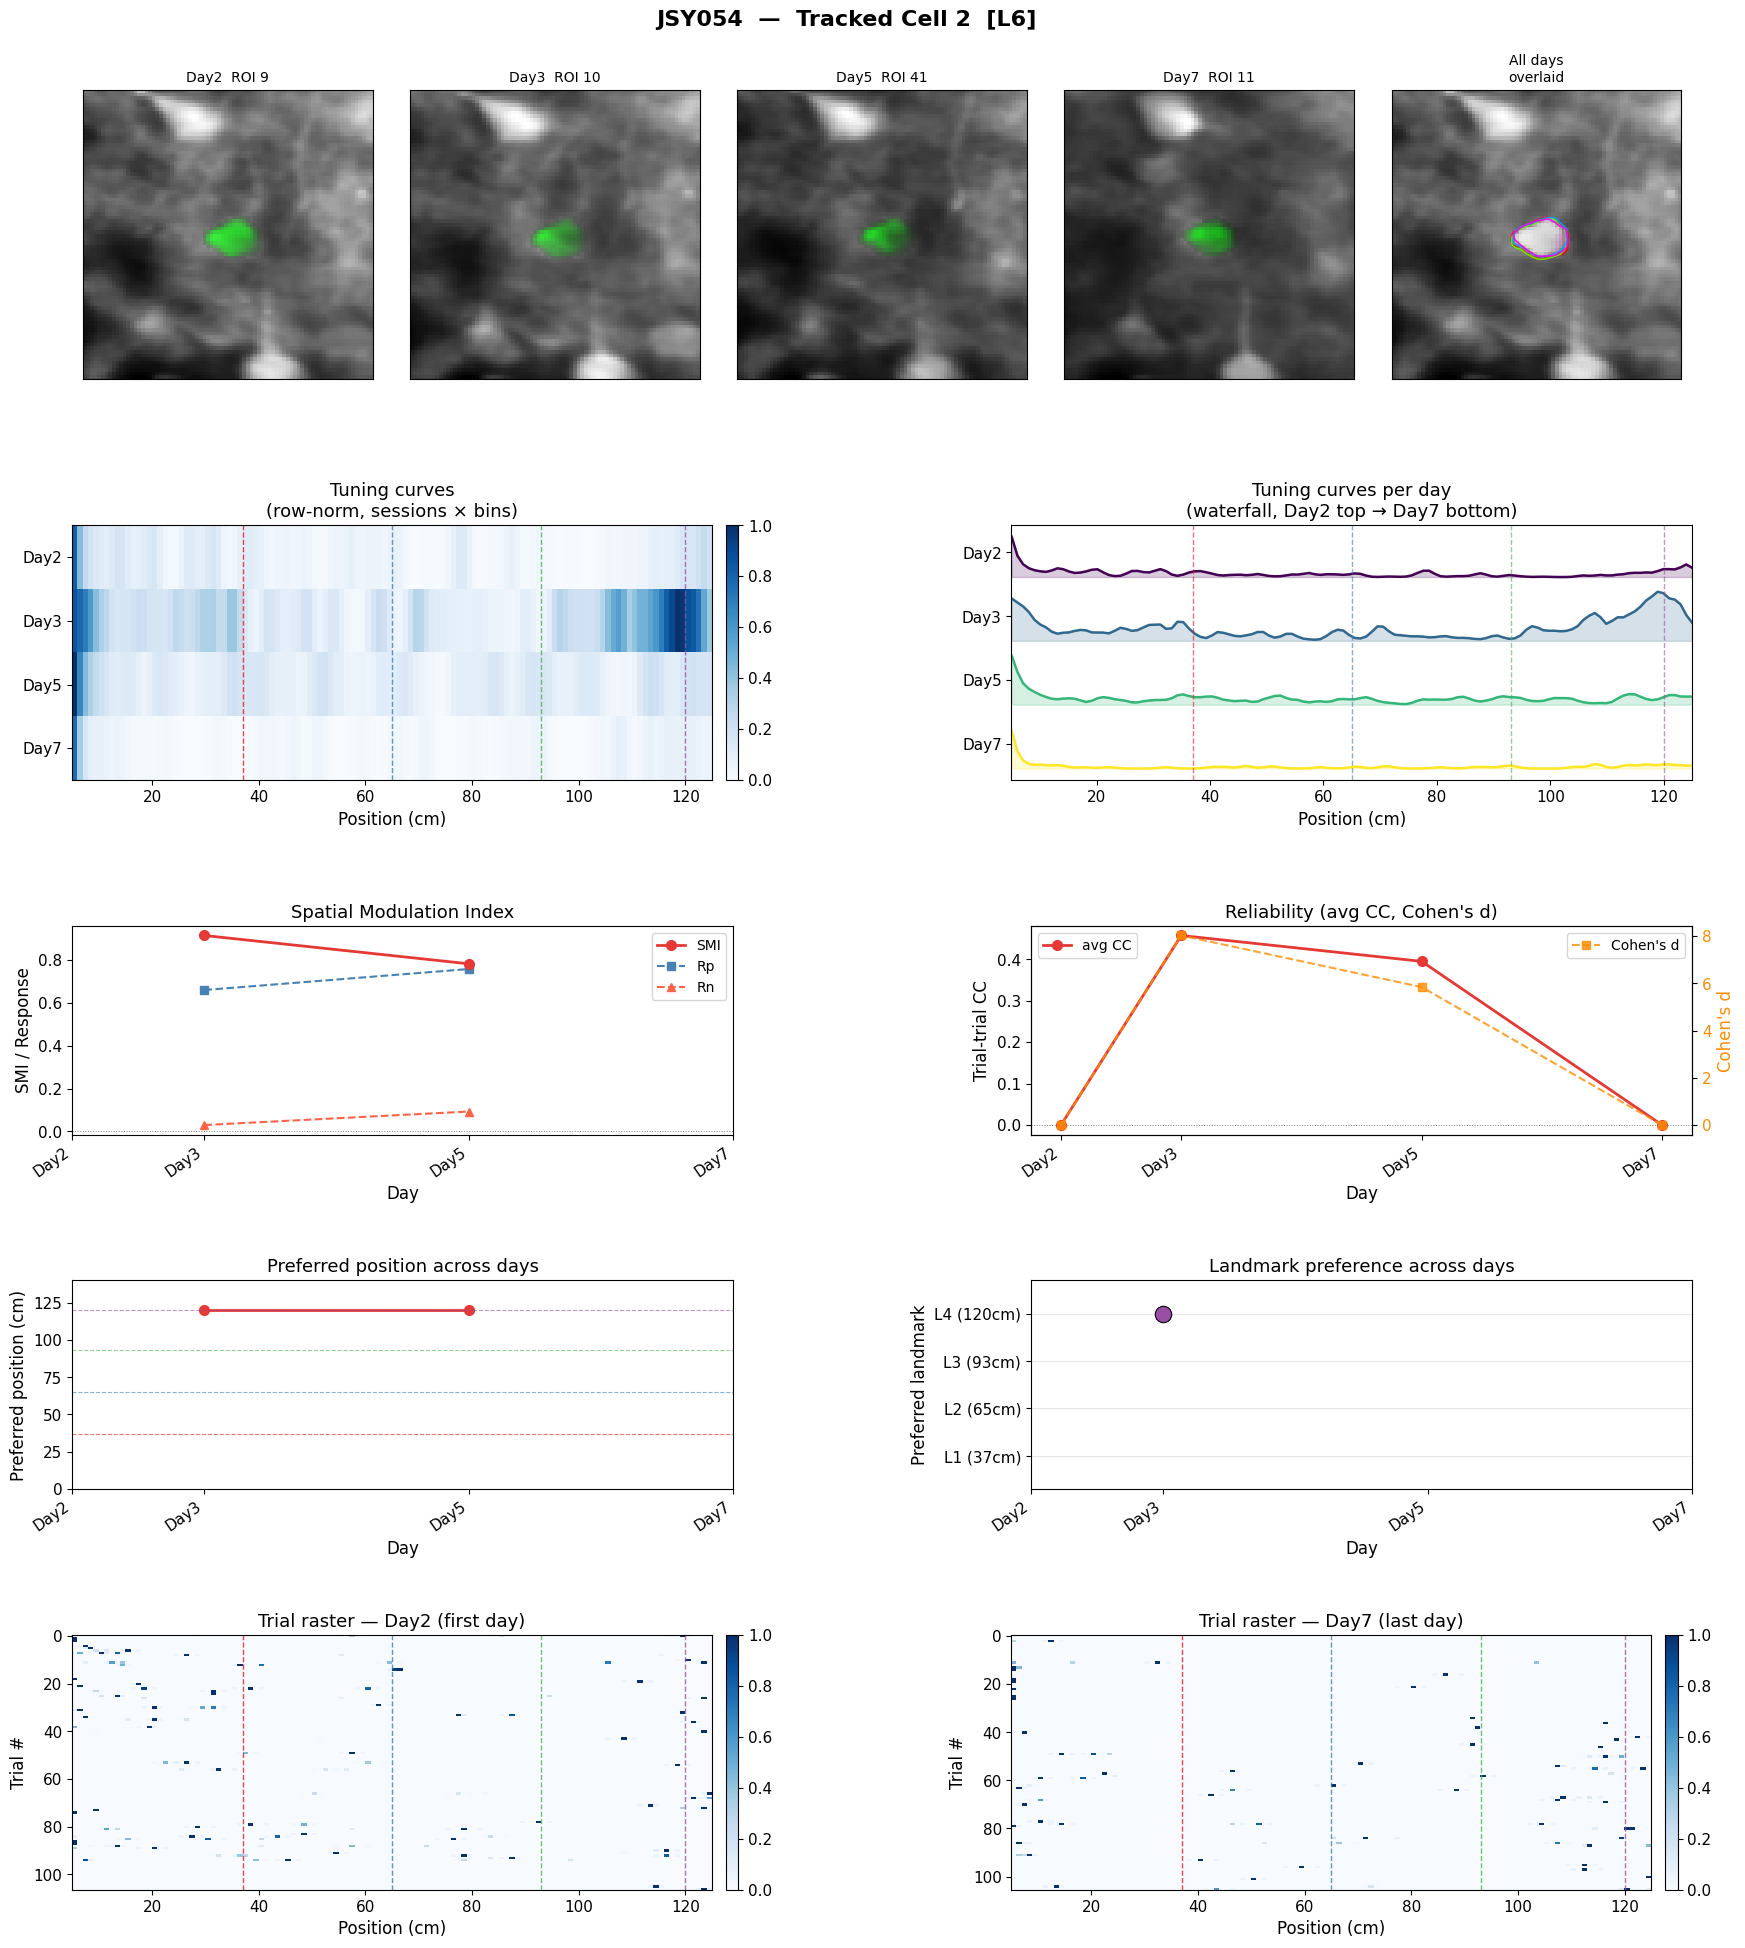

In [61]:
# Quick preview — change the index to any cell_row you want to inspect
PREVIEW_CELL = cells_to_plot[0] if len(cells_to_plot) > 0 else 0

%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline')

fig = plot_cell_figure(PREVIEW_CELL)
plt.tight_layout()
plt.show()

## Save all cells to PDF

## First vs Last Day Comparison — SMI & Landmark Preference by Layer

Two figures:
1. **Strict** — only cells present on both Day2 (first) and Day7 (last)
2. **Flexible** — all tracked cells, each using its own first and last valid session

Strict pairs (DayDay2 & DayDay7): 38 / 162 cells
Flexible pairs: 97 / 162 cells
  Cell 2: first=Day3, last=Day5
  Cell 5: first=Day3, last=Day7
  Cell 6: first=Day2, last=Day7
  Cell 7: first=Day3, last=Day7
  Cell 15: first=Day2, last=Day5
  Saved: JSY054_firstlast_strict.pdf


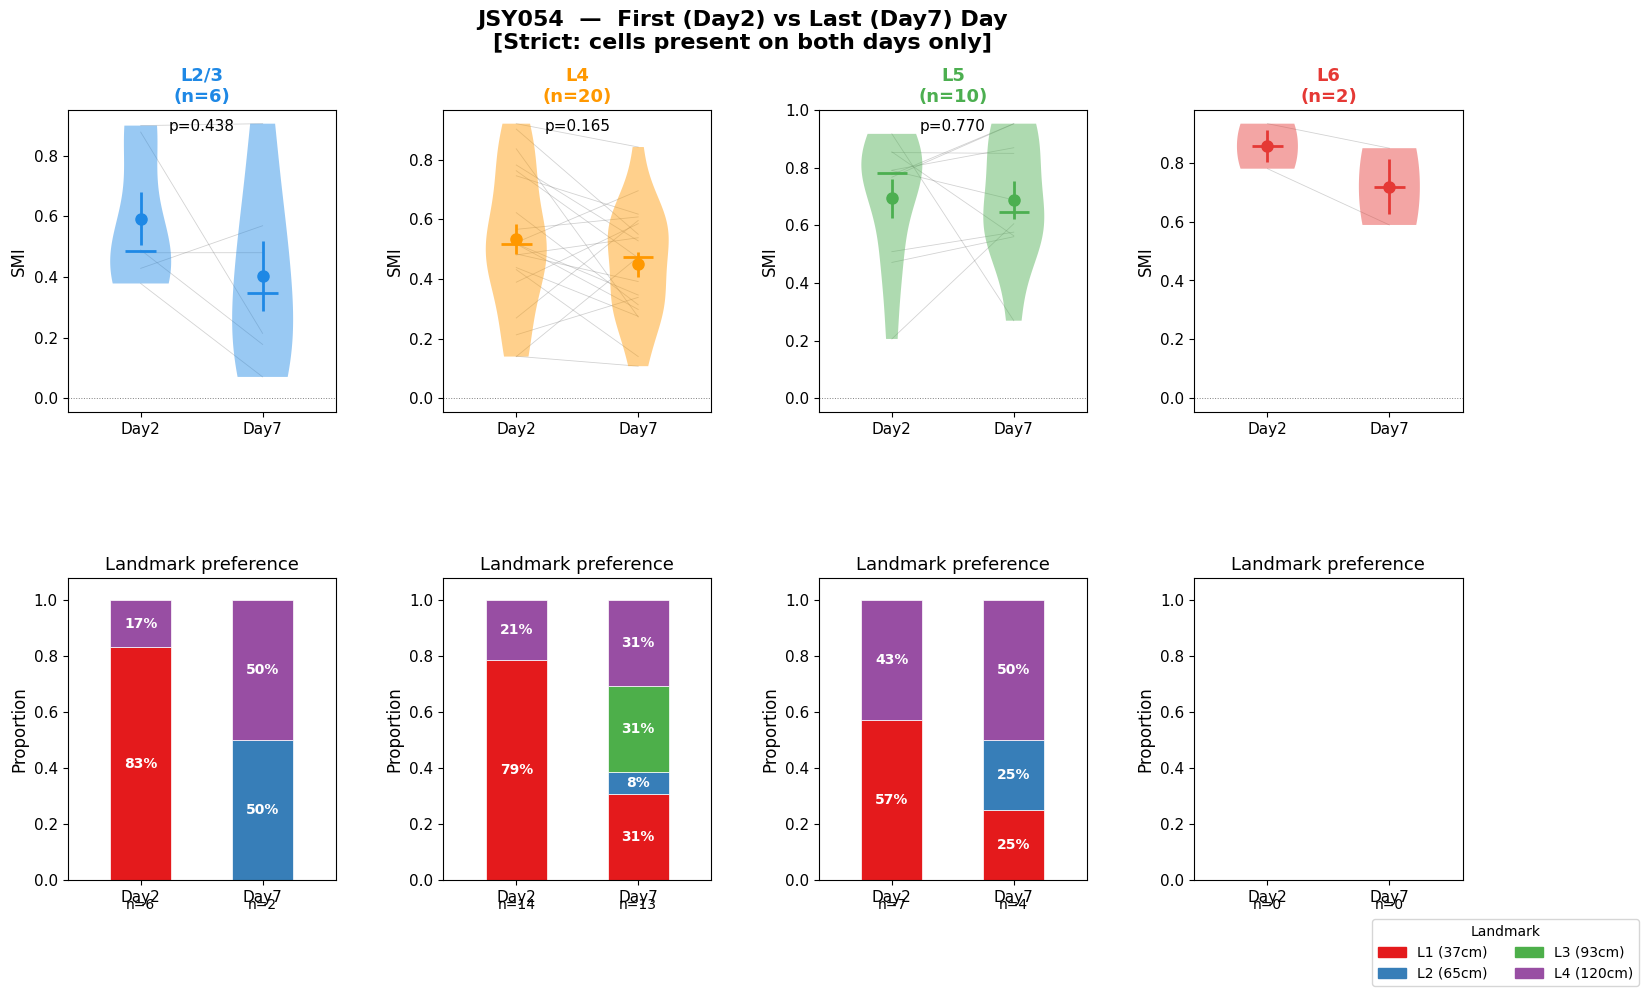

  Saved: JSY054_firstlast_flexible.pdf


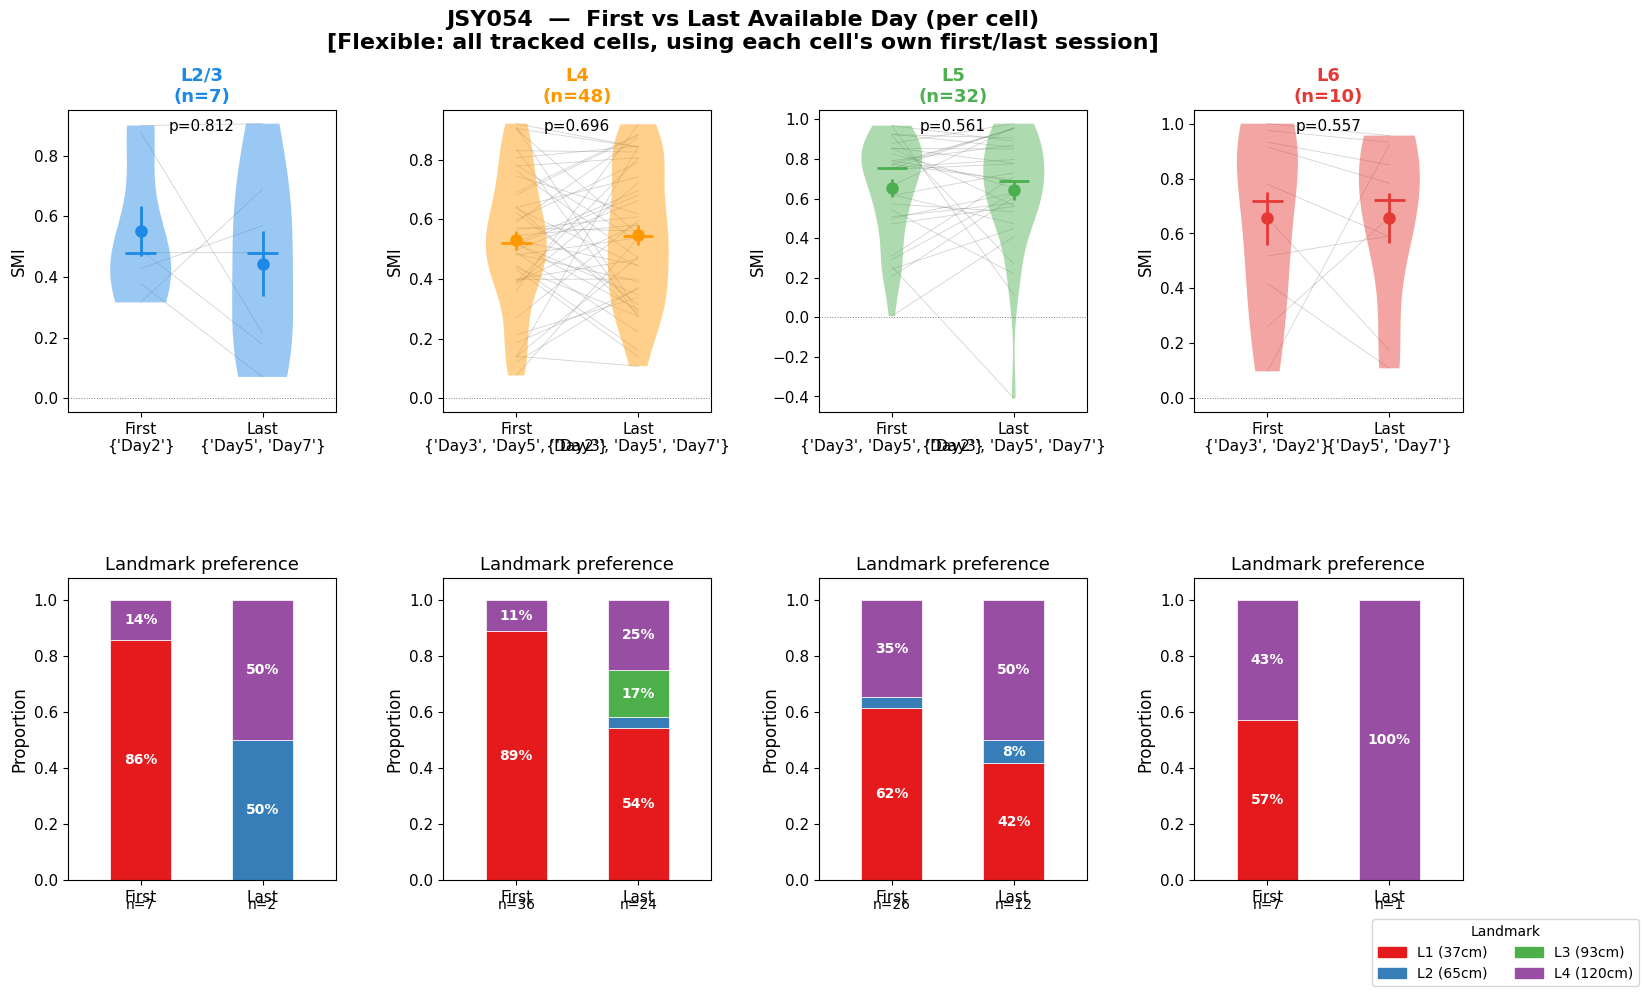

In [62]:
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats

# ── Build strict pairs (Day2 & Day7 both present) ────────────────────────────
first_col = 0
last_col  = n_sessions - 1

strict_valid = (~np.isnan(smi_matrix[:, first_col])) & (~np.isnan(smi_matrix[:, last_col]))
print(f"Strict pairs (Day{day_labels[first_col]} & Day{day_labels[last_col]}): "
      f"{strict_valid.sum()} / {n_tracked} cells")

# ── Build flexible pairs (each cell's own first/last valid session) ───────────
smi_flex_first  = np.full(n_tracked, np.nan)
smi_flex_last   = np.full(n_tracked, np.nan)
lm_flex_first   = np.full(n_tracked, -1, dtype=int)
lm_flex_last    = np.full(n_tracked, -1, dtype=int)
flex_first_col  = np.full(n_tracked, -1, dtype=int)
flex_last_col   = np.full(n_tracked, -1, dtype=int)

for row in range(n_tracked):
    valid_cols = np.where(~np.isnan(smi_matrix[row]))[0]
    if len(valid_cols) >= 2:
        fc = valid_cols[0];  lc = valid_cols[-1]
        smi_flex_first[row] = smi_matrix[row, fc]
        smi_flex_last[row]  = smi_matrix[row, lc]
        lm_flex_first[row]  = lm_matrix[row, fc]
        lm_flex_last[row]   = lm_matrix[row, lc]
        flex_first_col[row] = fc
        flex_last_col[row]  = lc

flex_valid = ~np.isnan(smi_flex_first)
print(f"Flexible pairs: {flex_valid.sum()} / {n_tracked} cells")
for row in np.where(flex_valid)[0][:5]:
    print(f"  Cell {row}: first={day_labels[flex_first_col[row]]}, "
          f"last={day_labels[flex_last_col[row]]}")


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_first_last_comparison(smi_first, smi_last, lm_first, lm_last,
                                valid_mask, flex_first_col_arr, flex_last_col_arr,
                                title, save_path=None):
    """
    Two-panel-group figure:
      Row 0: SMI per layer — violin + paired lines (first vs last)
      Row 1: Landmark preference per layer — stacked bar (first | last)
    """
    layers_present = [l for l in LAYER_ORDER if l in cell_layers and
                      np.any(valid_mask[cell_layers[l]])]
    n_layers = len(layers_present)
    if n_layers == 0:
        print("No layers with valid data."); return None

    fig, axes = plt.subplots(2, n_layers,
                             figsize=(4.5 * n_layers, 10),
                             gridspec_kw={'hspace': 0.55, 'wspace': 0.4})
    if n_layers == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(title, fontsize=FS_SUPTITLE, fontweight='bold')

    n_lm = len(LANDMARK_POSITIONS)
    _day_arr = np.array(day_labels)

    for li, layer in enumerate(layers_present):
        rows   = cell_layers[layer]
        vmask  = valid_mask[rows]
        rows_v = rows[vmask]
        if len(rows_v) == 0:
            continue

        s_first = smi_first[rows_v]
        s_last  = smi_last[rows_v]
        l_first = lm_first[rows_v]
        l_last  = lm_last[rows_v]
        lc      = LAYER_COLORS[layer]

        # ── SMI violin + paired lines ──────────────────────────────────────
        ax = axes[0, li]

        # Individual paired lines (light, behind)
        for sf, sl in zip(s_first, s_last):
            ax.plot([0, 1], [sf, sl], color='gray', lw=0.6, alpha=0.35, zorder=1)

        # Violins
        parts = ax.violinplot([s_first, s_last], positions=[0, 1],
                              showmedians=True, showextrema=False, widths=0.5)
        for pc in parts['bodies']:
            pc.set_facecolor(lc); pc.set_alpha(0.45)
        parts['cmedians'].set_color(lc); parts['cmedians'].set_linewidth(2)

        # Mean ± SEM dots
        for xi, vals in [(0, s_first), (1, s_last)]:
            m = np.nanmean(vals); se = np.nanstd(vals) / np.sqrt(np.sum(~np.isnan(vals)))
            ax.errorbar(xi, m, yerr=se, fmt='o', color=lc, ms=8, lw=2, zorder=5)

        # Wilcoxon test
        try:
            both = ~np.isnan(s_first) & ~np.isnan(s_last)
            if both.sum() >= 5:
                _, pval = scipy_stats.wilcoxon(s_first[both], s_last[both])
                pstr = f'p={pval:.3f}' if pval >= 0.001 else 'p<0.001'
                ax.text(0.5, 0.97, pstr, ha='center', va='top',
                        transform=ax.transAxes, fontsize=FS_TICK, color='k')
        except Exception:
            pass

        # Flexible mode: annotate which days are "first/last" if mixed
        if flex_first_col_arr is not None:
            fc_cols = flex_first_col_arr[rows_v]
            lc_cols = flex_last_col_arr[rows_v]
            fc_days = set(_day_arr[fc_cols[fc_cols >= 0]])
            lc_days = set(_day_arr[lc_cols[lc_cols >= 0]])
            ax.set_xticks([0, 1])
            ax.set_xticklabels([f'First\n{fc_days}', f'Last\n{lc_days}'], fontsize=FS_TICK - 1)
        else:
            ax.set_xticks([0, 1])
            ax.set_xticklabels([day_labels[first_col], day_labels[last_col]], fontsize=FS_TICK)

        ax.set_ylabel('SMI', fontsize=FS_LABEL)
        ax.set_title(f'{layer}\n(n={len(rows_v)})', fontsize=FS_TITLE, color=lc, fontweight='bold')
        ax.axhline(0, color='gray', lw=0.7, linestyle=':')
        ax.tick_params(labelsize=FS_TICK)
        ax.set_xlim(-0.6, 1.6)

        # ── Landmark preference stacked bars ──────────────────────────────
        ax2 = axes[1, li]

        for xi, lm_arr, label in [(0, l_first, 'First'), (1, l_last, 'Last')]:
            valid_lm = lm_arr[lm_arr >= 0]
            total    = len(valid_lm)
            bottom   = 0
            for lm_idx in range(n_lm):
                count = np.sum(valid_lm == lm_idx)
                if count == 0: continue
                prop  = count / total if total > 0 else 0
                ax2.bar(xi, prop, bottom=bottom, color=LANDMARK_COLORS[lm_idx],
                        width=0.5, edgecolor='white', linewidth=0.5)
                if prop > 0.06:
                    ax2.text(xi, bottom + prop / 2, f'{prop*100:.0f}%',
                             ha='center', va='center', fontsize=FS_TICK - 1,
                             color='white', fontweight='bold')
                bottom += prop
            # Annotate n
            ax2.text(xi, -0.06, f'n={total}', ha='center', va='top',
                     fontsize=FS_TICK - 1, transform=ax2.get_xaxis_transform())

        ax2.set_xticks([0, 1])
        if flex_first_col_arr is not None:
            ax2.set_xticklabels(['First', 'Last'], fontsize=FS_TICK)
        else:
            ax2.set_xticklabels([day_labels[first_col], day_labels[last_col]], fontsize=FS_TICK)
        ax2.set_ylabel('Proportion', fontsize=FS_LABEL)
        ax2.set_title('Landmark preference', fontsize=FS_TITLE)
        ax2.set_ylim(0, 1.08)
        ax2.tick_params(labelsize=FS_TICK)
        ax2.set_xlim(-0.6, 1.6)

    # Legend for landmarks (bottom right)
    patches = [mpatches.Patch(color=LANDMARK_COLORS[i], label=LANDMARK_LABELS[i])
               for i in range(n_lm)]
    fig.legend(handles=patches, loc='lower right', fontsize=FS_LEGEND,
               title='Landmark', title_fontsize=FS_LEGEND, ncol=2)

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"  Saved: {os.path.basename(save_path)}")
    return fig


# ── Figure 1: Strict pairs ────────────────────────────────────────────────────
%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline')

fig1 = plot_first_last_comparison(
    smi_first  = smi_matrix[:, first_col],
    smi_last   = smi_matrix[:, last_col],
    lm_first   = lm_matrix[:, first_col],
    lm_last    = lm_matrix[:, last_col],
    valid_mask = strict_valid,
    flex_first_col_arr = None,
    flex_last_col_arr  = None,
    title = (f"{animal_id}  —  First ({day_labels[first_col]}) vs Last ({day_labels[last_col]}) Day\n"
             f"[Strict: cells present on both days only]"),
    save_path = os.path.join(OUTPUT_DIR, f"{animal_id}_firstlast_strict.pdf")
)
plt.show()

# ── Figure 2: Flexible pairs ──────────────────────────────────────────────────
fig2 = plot_first_last_comparison(
    smi_first  = smi_flex_first,
    smi_last   = smi_flex_last,
    lm_first   = lm_flex_first,
    lm_last    = lm_flex_last,
    valid_mask = flex_valid,
    flex_first_col_arr = flex_first_col,
    flex_last_col_arr  = flex_last_col,
    title = (f"{animal_id}  —  First vs Last Available Day (per cell)\n"
             f"[Flexible: all tracked cells, using each cell's own first/last session]"),
    save_path = os.path.join(OUTPUT_DIR, f"{animal_id}_firstlast_flexible.pdf")
)
plt.show()

## Population heatmap across days

All tracked cells sorted by their preferred position on the reference day.  
One heatmap panel per session — shows how the population spatial code evolves.

Population heatmap: 90 cells sorted by Day2 preferred position
Saved: JSY054_population_heatmap.pdf


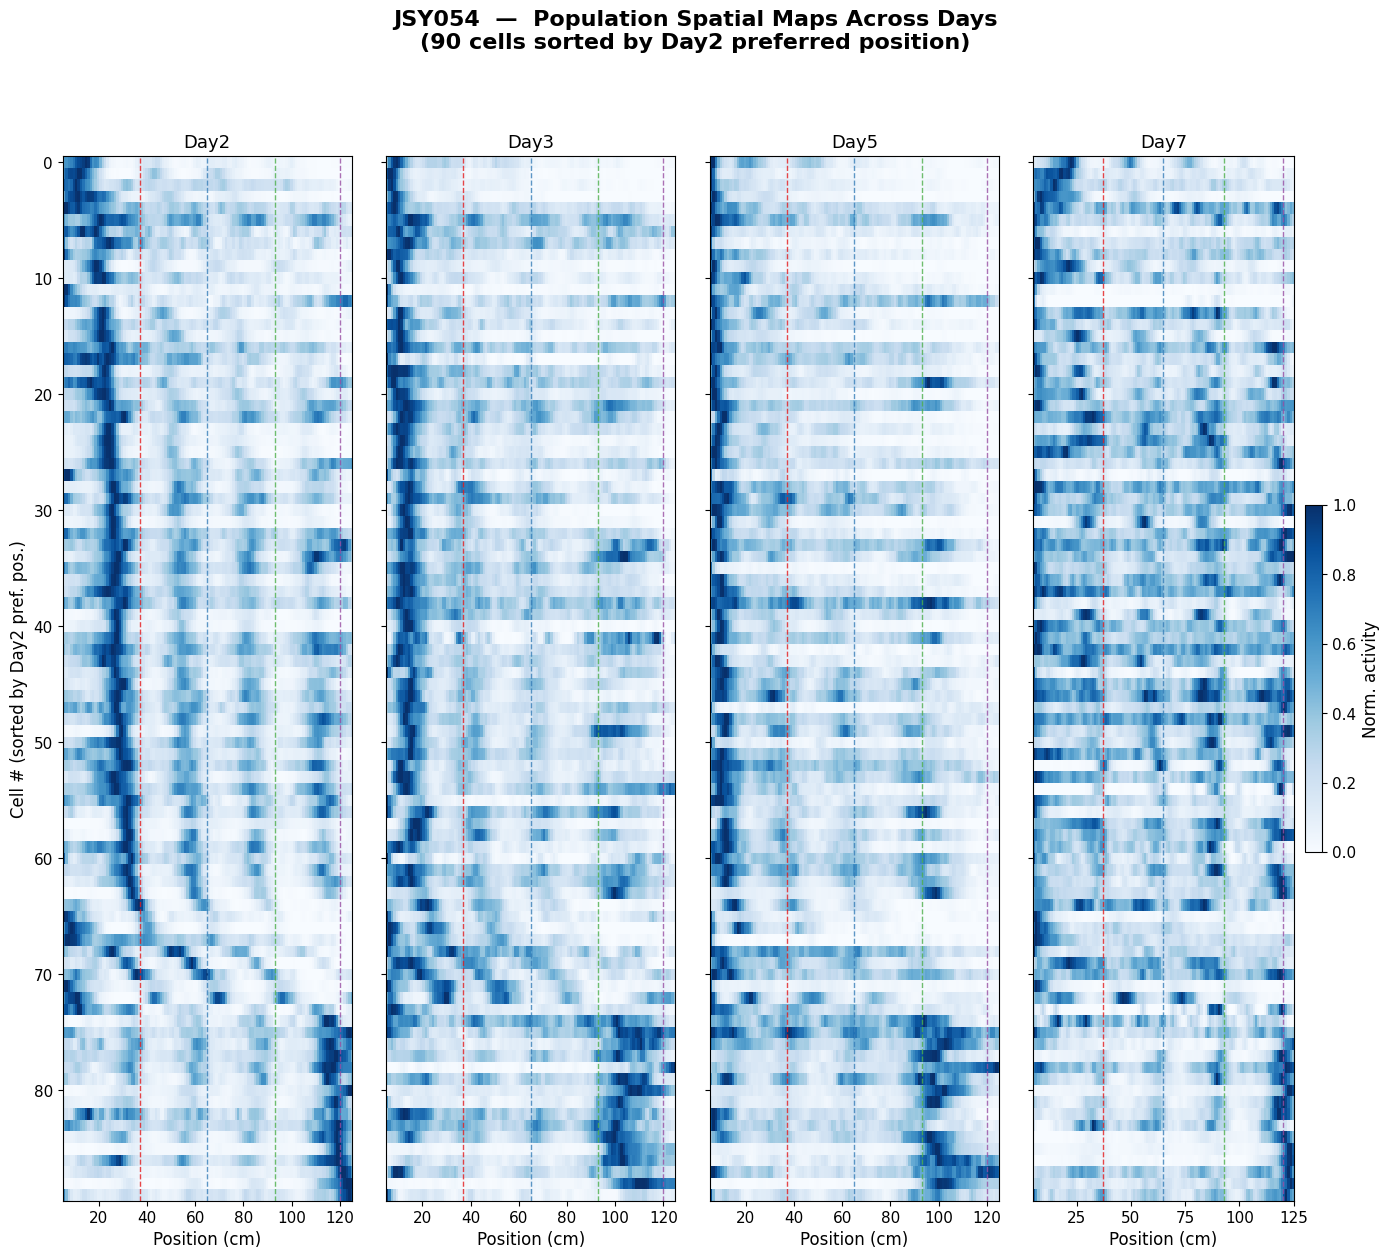

In [63]:
%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline')

# Sort tracked cells by preferred position on reference day
ref_col_for_pop  = day_labels.index(REFERENCE_DAY)
pref_pos_ref_vec = pref_pos_mat[:, ref_col_for_pop]
valid_pop_mask   = ~np.isnan(pref_pos_ref_vec)
valid_pop_rows   = np.where(valid_pop_mask)[0]
sort_order_pop   = np.argsort(pref_pos_ref_vec[valid_pop_mask])
sorted_pop_rows  = valid_pop_rows[sort_order_pop]
n_pop = len(sorted_pop_rows)
print(f"Population heatmap: {n_pop} cells sorted by {REFERENCE_DAY} preferred position")

fig_pop, axes_pop = plt.subplots(
    1, n_sessions,
    figsize=(3.5 * n_sessions, max(6, n_pop * 0.12 + 2)),
    sharey=True
)
if n_sessions == 1:
    axes_pop = [axes_pop]

for col, day in enumerate(day_labels):
    ax = axes_pop[col]

    if col not in tuning_curves:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                transform=ax.transAxes, fontsize=FS_LABEL)
        ax.set_title(day, fontsize=FS_TITLE)
        continue

    bc_d = bin_centers_by_day.get(col, bin_centers_ref)
    if bc_d is None:
        bc_d = bin_centers_ref
    trim_m    = (bc_d >= TUNING_X_MIN) & (bc_d <= TUNING_X_MAX)
    bc_trim_d = bc_d[trim_m]
    tc_day    = tuning_curves[col]  # (n_tracked, n_bins)

    hmap_pop = np.full((n_pop, int(trim_m.sum())), np.nan)
    for i, row in enumerate(sorted_pop_rows):
        tc_row = tc_day[row]
        if np.all(np.isnan(tc_row)):
            continue
        if len(tc_row) != len(bc_d):
            tc_row = np.interp(bc_d, np.linspace(bc_d[0], bc_d[-1], len(tc_row)), tc_row)
        hmap_pop[i] = tc_row[trim_m]

    im_pop = ax.imshow(
        hmap_pop, aspect='auto', cmap='Blues', vmin=0, vmax=1,
        origin='upper', interpolation='nearest',
        extent=[TUNING_X_MIN, TUNING_X_MAX, n_pop - 0.5, -0.5]
    )
    for lp, lc in zip(LANDMARK_POSITIONS, LANDMARK_COLORS):
        if TUNING_X_MIN <= lp <= TUNING_X_MAX:
            ax.axvline(lp, color=lc, lw=1, alpha=0.8, linestyle='--')

    ax.set_title(day, fontsize=FS_TITLE)
    ax.set_xlabel('Position (cm)', fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlim(TUNING_X_MIN, TUNING_X_MAX)
    if col == 0:
        ax.set_ylabel(f'Cell # (sorted by {REFERENCE_DAY} pref. pos.)', fontsize=FS_LABEL)
    if col == n_sessions - 1:
        cbar_pop = plt.colorbar(im_pop, ax=ax, fraction=0.06, pad=0.04)
        cbar_pop.set_label('Norm. activity', fontsize=FS_LABEL)
        cbar_pop.ax.tick_params(labelsize=FS_TICK)

fig_pop.suptitle(
    f"{animal_id}  —  Population Spatial Maps Across Days\n"
    f"({n_pop} cells sorted by {REFERENCE_DAY} preferred position)",
    fontsize=FS_SUPTITLE, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

pop_hmap_path = os.path.join(OUTPUT_DIR, f"{animal_id}_population_heatmap.pdf")
fig_pop.savefig(pop_hmap_path, dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.basename(pop_hmap_path)}")
plt.show()

In [64]:
import re as _re
matplotlib.use('Agg')

animal_id_safe = _re.sub(r'[^\w]', '_', animal_id)
pdf_path = os.path.join(OUTPUT_DIR, f"{animal_id_safe}_tracked_cells_comprehensive.pdf")

with PdfPages(pdf_path) as pdf:
    for k, cell_row in enumerate(cells_to_plot):
        if k % 10 == 0:
            print(f"  Plotting cell {k+1}/{len(cells_to_plot)} (row {cell_row})...")
        try:
            fig = plot_cell_figure(cell_row)
            pdf.savefig(fig, bbox_inches='tight')
        except Exception as e:
            print(f"    WARNING: cell {cell_row} failed — {e}")
        finally:
            plt.close('all')

print(f"\nSaved: {pdf_path}")
print(f"Total pages: {len(cells_to_plot)}")

  Plotting cell 1/136 (row 2)...
  Plotting cell 11/136 (row 18)...
  Plotting cell 21/136 (row 30)...
  Plotting cell 31/136 (row 44)...
  Plotting cell 41/136 (row 56)...
  Plotting cell 51/136 (row 69)...
  Plotting cell 61/136 (row 81)...
  Plotting cell 71/136 (row 91)...
  Plotting cell 81/136 (row 103)...
  Plotting cell 91/136 (row 115)...
  Plotting cell 101/136 (row 126)...
  Plotting cell 111/136 (row 136)...
  Plotting cell 121/136 (row 146)...
  Plotting cell 131/136 (row 156)...

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\TrackedROIs\comprehensive2357\JSY054_tracked_cells_comprehensive.pdf
Total pages: 136
